In [1]:
##esercizio regressione lineare Multipla

#https://frenzy86.s3.eu-west-2.amazonaws.com/python/data/Startup.csv
#https://frenzy86.s3.eu-west-2.amazonaws.com/python/data/Company.csv

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [39]:
#path = "https://frenzy86.s3.eu-west-2.amazonaws.com/python/data/Startup.csv"
path = "https://frenzy86.s3.eu-west-2.amazonaws.com/python/data/Company.csv"

df = pd.read_csv(path)
df

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,14.0
197,177.0,9.3,6.4,14.8
198,283.6,42.0,66.2,25.5


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [41]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
TV,200.0,147.0425,85.854236,0.7,74.375,149.75,218.825,296.4
Radio,200.0,23.2640,14.846809,0.0,9.975,22.90,36.525,49.6
Newspaper,200.0,30.5540,21.778621,0.3,12.750,25.75,45.100,114.0
Sales,200.0,15.1305,5.283892,1.6,11.000,16.00,19.050,27.0


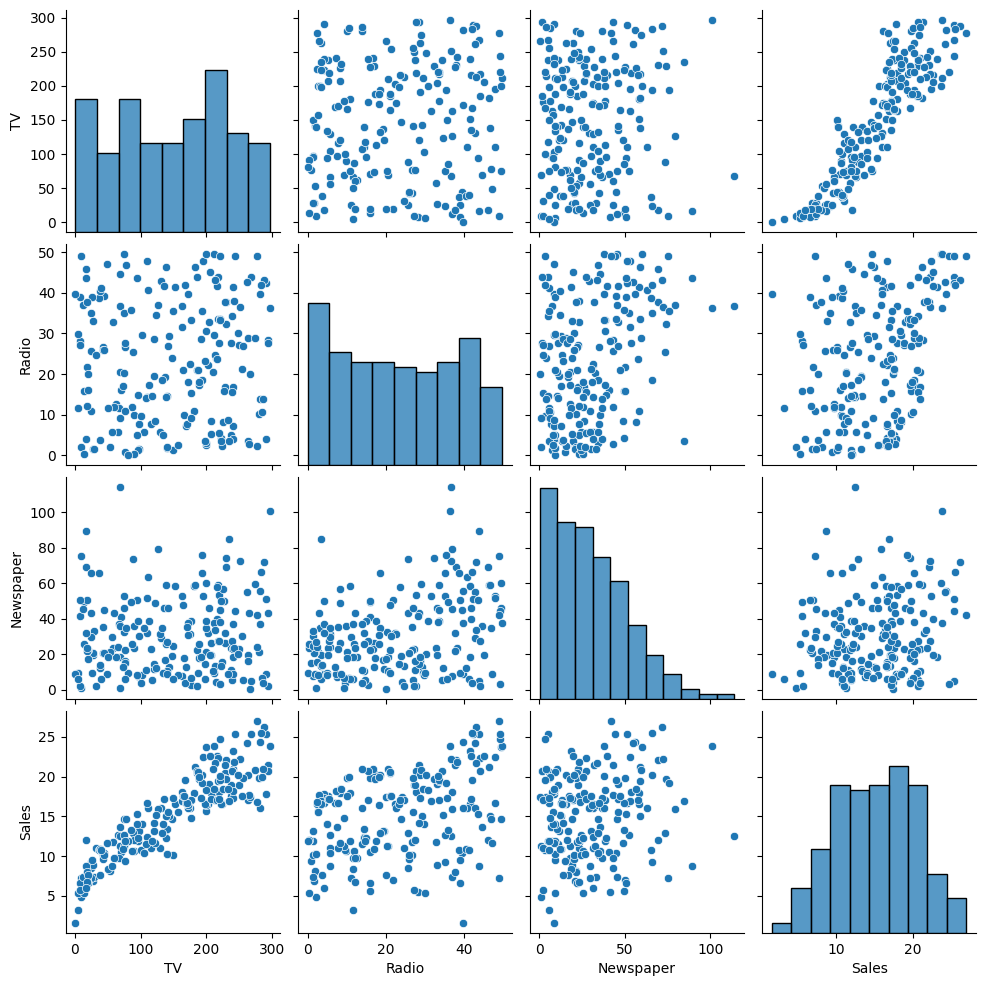

In [42]:
sns.pairplot(df)

In [43]:
df.corr()

,TV,Radio,Newspaper,Sales
TV,1.000000,0.054809,0.056648,0.901208
Radio,0.054809,1.000000,0.354104,0.349631
Newspaper,0.056648,0.354104,1.000000,0.157960
Sales,0.901208,0.349631,0.157960,1.000000


<Axes: >

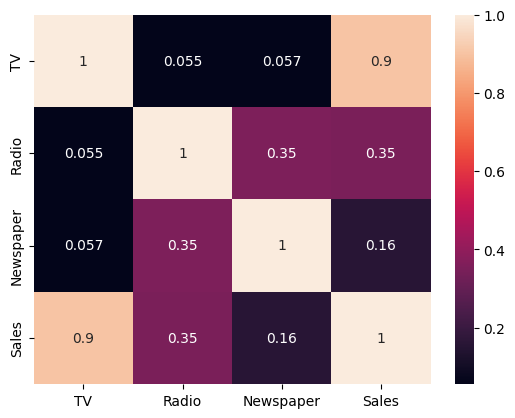

In [44]:
sns.heatmap(df.corr(),annot=True)

In [45]:
df.columns

Index(['TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')

In [47]:
#features
#target = 'Profit'
target = 'Sales'

# X = df.drop(columns=target) #df[['R&D Spend', 'Administration', 'Marketing Spend']]
X = df.drop(columns=target) #df[['TV', 'Radio', 'Newspaper', 'Sales']]

In [48]:
#target
y = df[target]

In [49]:
#divide dataset in training e test

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.3,
                                                    random_state=667,
                                                    )

In [50]:
X_train.shape

(140, 3)

In [51]:
X_test.shape

(60, 3)

In [53]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [54]:
## training del modello
model.fit(X_train,y_train)

LinearRegression()

In [55]:
model.intercept_

np.float64(4.638354794526759)

In [56]:
model.coef_

array([0.05464541, 0.09547516, 0.00658549])

In [57]:
## calcolare y_pred

y_pred = model.predict(X_test)
y_pred

array([20.21860589, 13.15443822,  9.77390948,  9.36626545, 13.60706294,
       10.29261136, 18.1999352 , 20.90765806,  9.67992495, 10.49757258,
       16.25720177, 21.22931058,  7.20436943, 11.56445131, 18.89091588,
        7.8937641 , 15.99496334, 15.55188716,  8.59931026, 12.54577838,
        8.98710965,  9.08150336, 24.93264536, 20.61892956, 10.90532846,
       12.38153605,  8.44922435, 18.73464472, 21.54808988, 13.73779686,
        6.43018346, 22.30986291,  7.16994737,  9.72407735, 17.75432157,
       11.11925496, 20.27566975,  7.37293474,  8.74881787, 15.94435597,
       20.14483986, 10.64089681,  9.09840359, 21.83184003, 17.21080121,
       14.75030574, 16.66628083, 10.32286932, 12.63706163, 18.33576883,
       11.06502354, 10.73930927, 10.70060579, 15.80930578, 18.94484656,
       19.69037211, 21.61841388, 23.43795499, 14.03768305, 18.04124834])

In [59]:
pd.DataFrame(list(zip(y_pred.round(),y_test)),columns=['predetti','reali'])

,predetti,reali
0,20.0,22.4
1,13.0,13.2
2,10.0,10.1
3,9.0,9.7
4,14.0,14.6
5,10.0,10.5
6,18.0,18.4
7,21.0,21.5
8,10.0,10.1
9,10.0,11.3


In [60]:
X_test.shape

(60, 3)

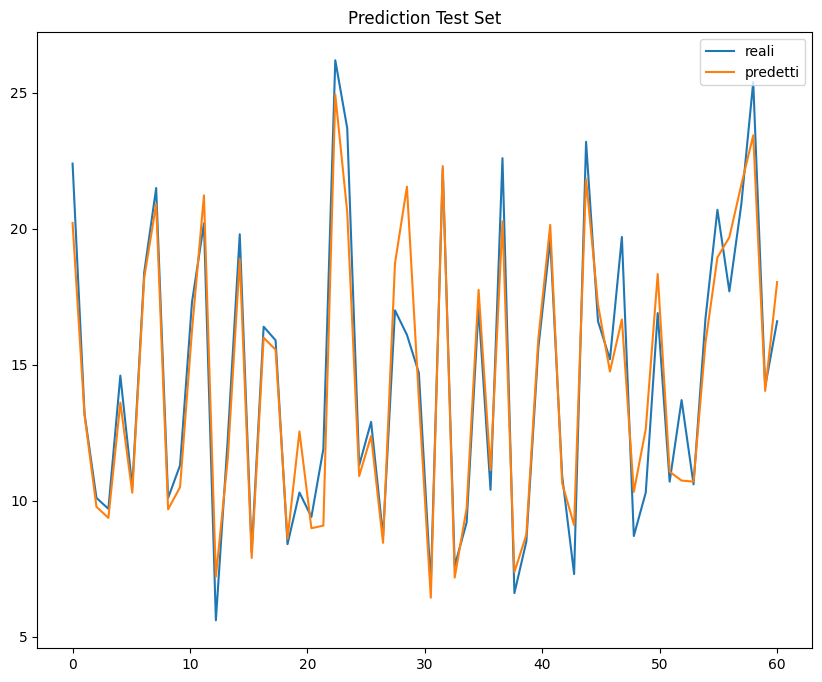

In [69]:
import numpy as np

lenght = X_test.shape[0]   # che è uguale a y_test.shape[0] è il numero di righe
x = np.linspace(0,lenght,lenght)

plt.figure(figsize=(10,8))
plt.plot(x,y_test,label='reali')
plt.plot(x,y_pred,label='predetti')
plt.title('Prediction Test Set')
plt.legend(loc=1)

In [63]:
# x1,x2,x3 = 70000,200000,120000 #company
x1,x2,x3 = 120,20,15 #startup

In [64]:
pred = model.predict([[x1,x2,x3]])
pred[0].round()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


np.float64(13.0)